<a href="https://colab.research.google.com/github/mikysetiawan/MachineLearningTerapan/blob/master/Tugas1_PredictiveAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading

---



In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import seaborn as sns

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input

In [45]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "sc231997/crude-oil-price",
    "crude-oil-price.csv"
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'crude-oil-price' dataset.
First 5 records:                         date  price  percentChange  change
0  1983-03-01 00:00:00+00:00  29.27            NaN     NaN
1  1983-04-01 00:00:00+00:00  30.63          4.646    1.36
2  1983-05-01 00:00:00+00:00  30.25         -1.241   -0.38
3  1983-06-01 00:00:00+00:00  31.38          3.736    1.13
4  1983-07-01 00:00:00+00:00  32.00          1.976    0.62


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           519 non-null    object 
 1   price          519 non-null    float64
 2   percentChange  518 non-null    float64
 3   change         518 non-null    float64
dtypes: float64(3), object(1)
memory usage: 16.3+ KB


In [47]:
df.describe()

,price,percentChange,change
count,519.000000,518.000000,518.000000
mean,47.256420,0.771880,0.129167
std,28.936642,10.588288,5.174808
min,10.420000,-54.245000,-32.830000
25%,20.580000,-5.165500,-1.740000
50%,37.050000,0.924500,0.260000
75%,69.825000,6.275750,2.437500
max,140.000000,88.376000,34.360000


In [48]:
price = (df.price == 0).sum()
date = (df.date == None).sum()
percentChange = (df.percentChange == None).sum()
change = (df.change == None).sum()

print("Nilai 0 di kolom price ada: ", price)
print("Nilai Null di kolom date ada: ", date)
print("Nilai Null di kolom percentChange ada: ", percentChange)
print("Nilai Null di kolom change ada: ", change)

Nilai 0 di kolom price ada:  0
Nilai Null di kolom date ada:  0
Nilai Null di kolom percentChange ada:  0
Nilai Null di kolom change ada:  0


# EDA

<Axes: xlabel='price'>

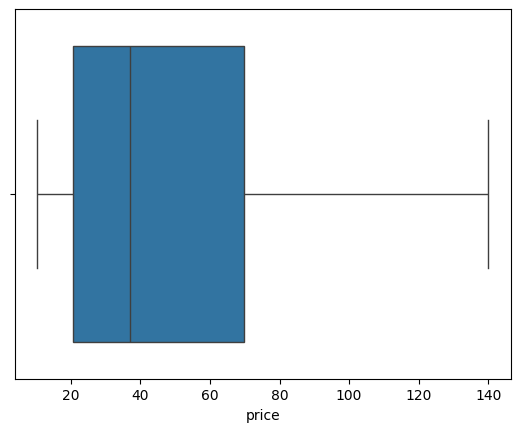

In [49]:
sns.boxplot(x=df['price'])

<Axes: xlabel='change'>

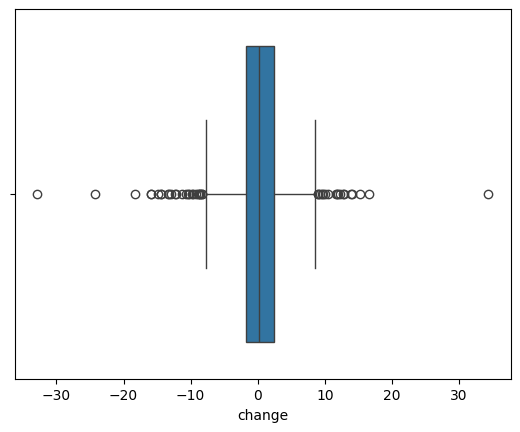

In [50]:
sns.boxplot(x=df['change'])

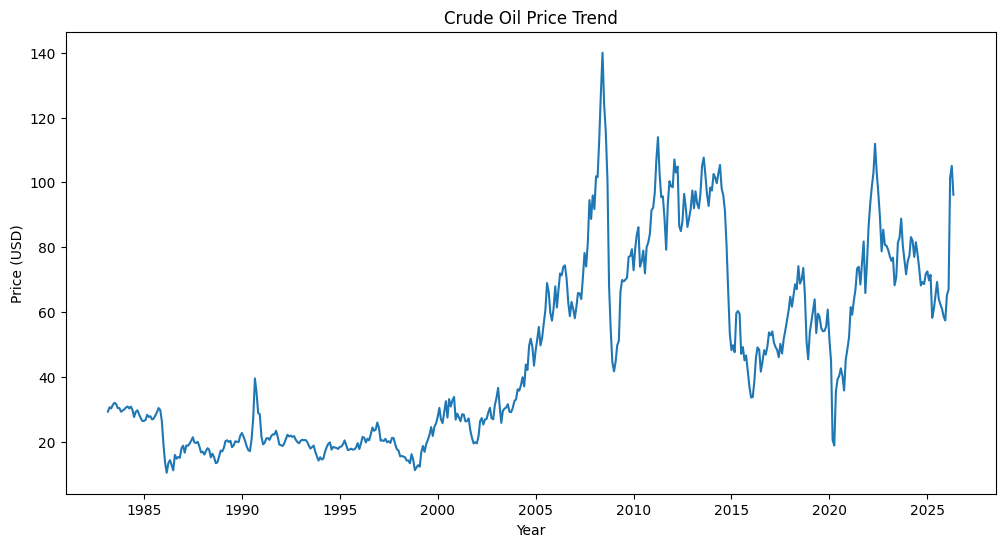

In [51]:
# Convert date to datetime and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Plotting the price trend
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['price'])
plt.title('Crude Oil Price Trend')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.show()

# Data Preprocessing

In [52]:
import numpy as np
import pandas as pd


# 1. Pastikan data terurut dan gunakan kolom price
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
data = df.filter(['price']).values

# 2. Scaling (Wajib untuk LSTM)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Membuat sequences (Windowing)
# Kita gunakan 60 hari sebelumnya untuk memprediksi hari berikutnya
window_size = 60
X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# 4. Reshape X agar sesuai format LSTM [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [53]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Using LSTM (Long Short-Term Memory) to calculating predictive time-series data

In [54]:
# Tentukan model menggunakan Input layer secara eksplisit
model = Sequential([
    # Menggunakan Input layer untuk mendefinisikan shape [time_steps, features]
    Input(shape=(X_train.shape[1], 1)),

    # Layer LSTM pertama
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),

    # Layer LSTM kedua
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),

    # Fully Connected layers
    Dense(units=25),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Tampilkan ringkasan model untuk memastikan arsitektur sudah benar
model.summary()

# Lanjutkan ke proses training
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_test, y_test)
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0319 - val_loss: 0.0218
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0183 - val_loss: 0.0140
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0124 - val_loss: 0.0137
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0109 - val_loss: 0.0130
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0102 - val_loss: 0.0128
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0094 - val_loss: 0.0119
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0095 - val_loss: 0.0123
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0077 - val_loss: 0.0112
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0076 - val_loss: 0.0108
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0080 - val_loss: 0.0103
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0082 - val_loss: 0.0106
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Test RMSE: 12.2732


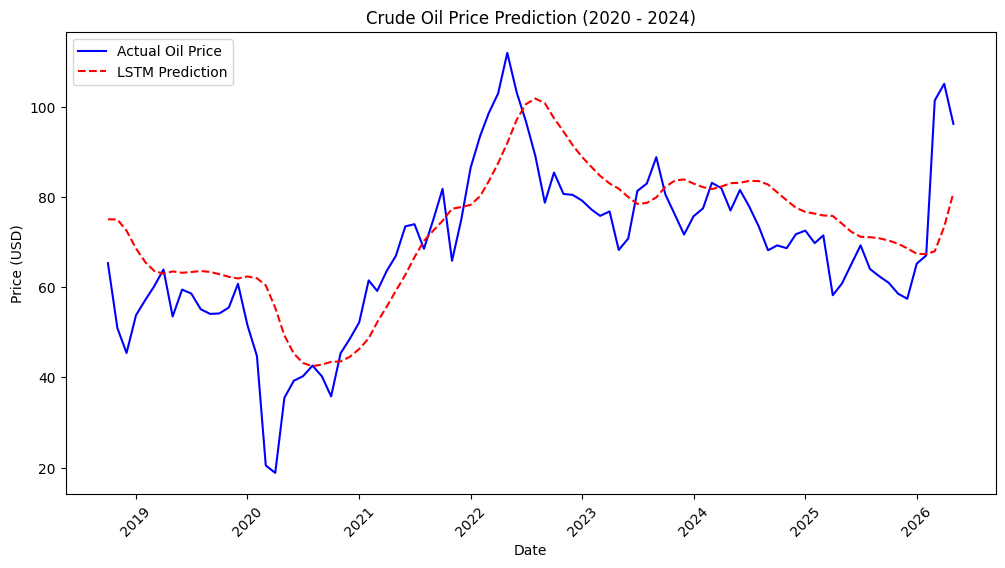

In [56]:
# Prediksi
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions) # Kembalikan ke harga asli

# Ambil harga asli (y_test) untuk perbandingan
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Hitung RMSE (Root Mean Squared Error)
rmse = np.sqrt(np.mean((predictions - y_test_unscaled)**2))
print(f'Test RMSE: {rmse:.4f}')

# 1. Ambil data tanggal yang sesuai dengan X_test
# Kita ambil tanggal mulai dari (window_size) sampai akhir
test_dates = df['date'].iloc[split + window_size:].values

plt.figure(figsize=(12, 6))

# 2. Masukkan test_dates sebagai sumbu X
plt.plot(test_dates, y_test_unscaled, label='Actual Oil Price', color='blue')
plt.plot(test_dates, predictions, label='LSTM Prediction', color='red', linestyle='--')

plt.title('Crude Oil Price Prediction (2020 - 2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.xticks(rotation=45) # Memutar label tanggal agar tidak bertumpuk
plt.show()